In [27]:
from importlib import import_module
import os
import sys
import argparse
import linecache
import uproot
import vector
import math
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from tqdm import tqdm  # ✅ 진행률 표시
import glob
import json
vector.register_awkward()


## HLT 를 먼저 통과 한 이벤트 , hlthps tau 0개 이상인 이벤트만 -> 남은 이벤트 중에서 gen match -> genmatch 가 된 hlthps 의 이벤트를 남겨 놓음  



def get_info (sample):
    file = uproot.open(sample)
    events = file["Events"]
    runs = file["Runs"]
    keys = events.keys()

    # 변수 불러오기 

    tau_pt = events["hltHpsPFTau_pt"].array()
    tau_eta = events["hltHpsPFTau_eta"].array()
    tau_phi = events["hltHpsPFTau_phi"].array()
    tau_mass = events["hltHpsPFTau_mass"].array()


    genvis_tau_pt = events["GenVisTau_pt"].array()
    genvis_tau_eta = events["GenVisTau_eta"].array()
    genvis_tau_phi = events["GenVisTau_phi"].array()
    genvis_tau_mass = events["GenVisTau_mass"].array()
    #print(len(genvis_tau_pt),"gen vis tau total events")

    # 필터 설정

    ## trigger filter ( returns_num_den 에서 사용됨  )
    tau_trigger_filter = events["HLT_LooseDeepTauPFTauHPS180_L2NN_eta2p1"].array()

    ## hlthpstau 1개 이상 필터 

    tau_num = ak.num(tau_pt)
    no_tau = (tau_num == 0) # [ False, True, False, ... ] 2000개 
    has_tau = ~no_tau
    hlt_has_tau_filter = (has_tau) ## hlthps tau 1개 이상 있는 이벤트만 선택

    tau_triggerd_list= (hlt_has_tau_filter==True)  
    
    ## final selected variables ( hlthps 있는 이벤트만 남김 )
    final_tau_pt = tau_pt[tau_triggerd_list]
    final_tau_eta = tau_eta[tau_triggerd_list]
    final_tau_phi = tau_phi[tau_triggerd_list]
    final_tau_mass = tau_mass[tau_triggerd_list]

    final_genvis_tau_pt = genvis_tau_pt[tau_triggerd_list]
    final_genvis_tau_eta = genvis_tau_eta[tau_triggerd_list]
    final_genvis_tau_phi = genvis_tau_phi[tau_triggerd_list]
    final_genvis_tau_mass = genvis_tau_mass[tau_triggerd_list]

    tau_trigger_filtered = tau_trigger_filter[tau_triggerd_list]



    print((final_tau_pt))
    print((final_genvis_tau_pt))
    total_events = len(tau_pt)
    print("total events:", total_events,"->","after trigger filter:",ak.sum(has_tau),"->","after reconstructed hlthps ,events remain",len(final_tau_pt))
    return events,final_tau_pt, final_tau_eta, final_tau_phi, final_tau_mass, final_genvis_tau_pt, final_genvis_tau_eta, final_genvis_tau_phi, final_genvis_tau_mass ,genvis_tau_pt , genvis_tau_eta , genvis_tau_phi ,tau_trigger_filtered


def deltaR(eta1,phi1,eta2,phi2):
    delta_eta = eta1 - eta2
    delta_phi = phi1 - phi2
    delta_phi = (delta_phi + math.pi) % (2 * math.pi) - math.pi
    return np.sqrt(delta_eta**2 + delta_phi**2)

def gen_match(tau_pt, tau_eta, tau_phi, genvis_tau_pt, genvis_tau_eta, genvis_tau_phi, deltaR_threshold=0.3,delta_pt_threshold=10):
    matched = [] ## gen 이벤트 인덱스 안에 들어있는 각 gen 입자의 매칭 여부 리스트 [[ True(event1 1 particle), False(event1 2 particle), ... ](event1), [ False, False, ... ](event2), ... ]
    events_flag = [] ## gen match 된 이벤트인지 아닌지 gen 이벤트의 bool 리스트 [ True(event1), False(event2), ... ]
    reco_matched = [] ## reco 이벤트 인덱스 안에 들어있는 각 reco 입자의 매칭 여부 리스트
    leading_matched = []
    subleading_matched = []
    both_matched = []

    for i in range(len(genvis_tau_pt)):
        # 1. 정렬
        reco_indices = ak.argsort(tau_pt[i], ascending=False)
        t_pt, t_eta, t_phi = tau_pt[i][reco_indices], tau_eta[i][reco_indices], tau_phi[i][reco_indices]
        
        # 2. 이번 이벤트의 상태 초기화 (이벤트 루프 시작할 때마다 초기화해야 함)
        reco_match_flag = [False] * len(t_pt) 
        match_flags = []
        has_genmatch = False
        leading_match = False
        subleading_match = False

        # Gen 입자 루프
        for j in range(len(genvis_tau_pt[i])):
            g_pt, g_eta, g_phi = genvis_tau_pt[i][j], genvis_tau_eta[i][j], genvis_tau_phi[i][j]
            is_matched = False
            
            # 3. Leading Reco Tau(인덱스 0)와 매칭 시도
            if len(t_pt) > 0:
                # k 루프 대신 인덱스 0 사용 (Leading)
                dR = deltaR(t_eta[0], t_phi[0], g_eta, g_phi)
                dpt = abs(t_pt[0] - g_pt)
                    
                if dR < deltaR_threshold and dpt < delta_pt_threshold:
                    is_matched = True
                    has_genmatch = True
                    reco_match_flag[0] = True # Leading 매칭 표시
                    leading_match = True      # 플래그 업데이트
                        # 만약 여기서 j(gen) 루프를 탈출하고 싶다면 break
            
            match_flags.append(is_matched)
        if has_genmatch:
            events_flag.append(True) # 이벤트 자체가 매칭된 이벤트인지 저장 
        else:
            events_flag.append(False)
        matched.append(np.array(match_flags)) ## 이벤트 당 match_flags(입자가 매칭됐는지를 리스트형태로 저장 )
        reco_matched.append(np.array(reco_match_flag))


    return both_matched,leading_matched , subleading_matched , matched ,events_flag , reco_matched


#sample = "/gv0/Users/achihwan/phase2/cmssw_16/condor/hltrun/step2_fullstack_180.root"
#events_180,final_tau_pt_180, final_tau_eta_180, final_tau_phi_180, final_tau_mass_180, final_genvis_tau_pt_180, final_genvis_tau_eta_180, final_genvis_tau_phi_180, final_genvis_tau_mass_180 ,genvis_tau_pt_180 , genvis_tau_eta_180, genvis_tau_phi_180,tau_trigger_filter_180= get_info(sample)
#both_matched_180, leading_only_matched_180 , subleading_only_matched_180,gen_matched_180,events_flag_180 = gen_match(final_tau_pt_180, final_tau_eta_180, final_tau_phi_180, final_genvis_tau_pt_180, final_genvis_tau_eta_180, final_genvis_tau_phi_180)


sample = "/gv0/Users/achihwan/phase2/cmssw_16/condor/hltrun/new_150.root"
events_150,final_tau_pt_150, final_tau_eta_150, final_tau_phi_150, final_tau_mass_150, final_genvis_tau_pt_150, final_genvis_tau_eta_150, final_genvis_tau_phi_150, final_genvis_tau_mass_150,genvis_tau_pt_150 , genvis_tau_eta_150, genvis_tau_phi_150,tau_trigger_filter_150 = get_info(sample)
both_matched_150, leading_only_matched_150 , subleading_only_matched_150,gen_matched_150,events_flag_150 , reco_matched_150= gen_match(final_tau_pt_150, final_tau_eta_150, final_tau_phi_150, final_genvis_tau_pt_150, final_genvis_tau_eta_150, final_genvis_tau_phi_150)




[[149, 36.3, 12.5, 8.54, 7.27, 7.06, ..., 1.21, 1.2, 1.18, 0.919, 0.925], ...]
[[203, 150], [126], [218], [146], ..., [92.2], [89, 60.8], [234, 40.6], [226]]
total events: 20000 -> after trigger filter: 12722 -> after reconstructed hlthps ,events remain 12722


In [1]:

import cmsstyle as CMS
import mplhep as hep
import matplotlib.pyplot as plt

## 리딩 서브리딩 아무거나 매칭 된 경우 
def returns_num_den (gen_matched, events_flag, final_tau_pt, final_tau_eta, final_tau_phi, final_genvis_tau_pt, final_genvis_tau_eta, final_genvis_tau_phi, genvis_tau_pt, genvis_tau_eta, genvis_tau_phi,tau_trigger_filter):

    ### denominator
    events_flag = np.array(events_flag)
    print(final_genvis_tau_pt)
    match_genvistau_pt = final_genvis_tau_pt[tau_trigger_filter] # including match + non-match
    print(match_genvistau_pt)
    match_genvistau_eta = final_genvis_tau_eta[tau_trigger_filter]
    match_genvistau_phi = final_genvis_tau_phi[tau_trigger_filter]
    den_eta_filter = np.abs(match_genvistau_eta) <= 2.1

    ## denominator ( 모든 genvistau 정보 )
    den_pt = match_genvistau_pt[den_eta_filter]
    den_eta = match_genvistau_eta[den_eta_filter]
    den_phi = match_genvistau_phi[den_eta_filter]



    ## numerator
    not_matched_events_flag = ~events_flag
    match_trigger_filter = not_matched_events_flag & tau_trigger_filter #& using_eta

    triggered_genvistau_pt = final_genvis_tau_pt[match_trigger_filter]
    triggered_genvistau_eta = final_genvis_tau_eta[match_trigger_filter]
    triggered_genvistau_phi = final_genvis_tau_phi[match_trigger_filter]
    
    num_eta_filter = np.abs(triggered_genvistau_eta) <= 2.1
    

    num_pt = triggered_genvistau_pt[num_eta_filter]
    num_eta = triggered_genvistau_eta[num_eta_filter]
    num_phi = triggered_genvistau_phi[num_eta_filter]
    

    ## getting leading 

    at_least_one_num = ak.num(num_pt)>0

    num_pt = num_pt[at_least_one_num]
    num_eta = num_eta[at_least_one_num]
    num_phi = num_phi[at_least_one_num]

    num_pt = num_pt[:,0]
    num_eta = num_eta[:,0]
    num_phi = num_phi[:,0]

    at_least_one_den = ak.num(den_pt)>0

    den_pt = den_pt[at_least_one_den]
    den_eta = den_eta[at_least_one_den]
    den_phi = den_phi[at_least_one_den]

    den_pt = den_pt[:,0]
    den_eta = den_eta[:,0]
    den_phi = den_phi[:,0]
        
    print(len(num_pt), "num length")
    print(len(den_pt), "den length")
    reco_tau_pt = final_tau_pt[match_trigger_filter]
    reco_tau_eta = final_tau_eta[match_trigger_filter]

    return num_pt, den_pt, num_eta, den_eta, num_phi, den_phi , reco_tau_pt ,reco_tau_eta

def returns_reco_num_den (gen_matched, events_flag, final_tau_pt, final_tau_eta, final_tau_phi, final_genvis_tau_pt, final_genvis_tau_eta, final_genvis_tau_phi, genvis_tau_pt, genvis_tau_eta, genvis_tau_phi,tau_trigger_filter):
    ### numerator 
    events_flag = np.array(events_flag)
    not_matched_events_flag = ~events_flag & tau_trigger_filter

    recotau_pt_num = final_tau_pt[not_matched_events_flag]
    recotau_eta_num = final_tau_eta[not_matched_events_flag]
    recotau_phi_num = final_tau_phi[not_matched_events_flag]
    
    max_values = np.max(recotau_pt_num, axis=1)
    max_indices = np.argmax(recotau_pt_num, axis=1)
    max_eta_list = []
    max_phi_list = []
    for i in range(len(max_values)):
        max_eta_list.append(recotau_eta_num[i][max_indices[i]])
        max_phi_list.append(recotau_phi_num[i][max_indices[i]])

    eta_filter = np.abs(np.array(max_eta_list)) <= 2.1
    max_values = max_values[eta_filter]
    max_eta_list = np.array(max_eta_list)[eta_filter]
    max_phi_list = np.array(max_phi_list)[eta_filter]


    ### denominator
    
    recotau_pt_den = final_tau_pt[tau_trigger_filter]
    recotau_eta_den = final_tau_eta[tau_trigger_filter]
    recotau_phi_den = final_tau_phi[tau_trigger_filter]

    max_values_den  = np.max(recotau_pt_den, axis=1)
    max_indices_den = np.argmax(recotau_pt_den, axis=1)
    max_eta_list_den = []
    max_phi_list_den = []
    for i in range(len(max_values_den)):
        max_eta_list_den.append(recotau_eta_den[i][max_indices_den[i]])
        max_phi_list_den.append(recotau_phi_den[i][max_indices_den[i]])

    eta_filter_den = np.abs(np.array(max_eta_list_den)) <= 2.1
    max_values_den = max_values_den[eta_filter_den]
    max_eta_list_den = np.array(max_eta_list_den)[eta_filter_den]
    max_phi_list_den = np.array(max_phi_list_den)[eta_filter_den]

    ############
    ############
    num_pt = max_values
    num_eta = max_eta_list
    num_phi = max_phi_list
    ## denominator ( 모든 genvistau 정보 )
    den_pt = max_values_den
    den_eta = max_eta_list_den
    den_phi = max_phi_list_den

    return num_pt, den_pt, num_eta, den_eta, num_phi, den_phi  


num_pt_150 , den_pt_150, num_eta_150, den_eta_150, num_phi_150, den_phi_150 = returns_reco_num_den (gen_matched_150, events_flag_150, final_tau_pt_150, final_tau_eta_150, final_tau_phi_150, final_genvis_tau_pt_150, final_genvis_tau_eta_150, final_genvis_tau_phi_150, genvis_tau_pt_150, genvis_tau_eta_150, genvis_tau_phi_150,tau_trigger_filter_150)
num_pt_gen_150 , den_pt_gen_150, num_eta_gen_150, den_eta_gen_150, num_phi_gen_150, den_phi_gen_150 , reco_tau_pt_150 , reco_tau_eta_150= returns_num_den (gen_matched_150, events_flag_150, final_tau_pt_150, final_tau_eta_150, final_tau_phi_150, final_genvis_tau_pt_150, final_genvis_tau_eta_150, final_genvis_tau_phi_150, genvis_tau_pt_150, genvis_tau_eta_150, genvis_tau_phi_150,tau_trigger_filter_150)
#pt 150 filter
print(len(num_pt_150))
print(len(den_pt_150))


####
#### reco plot 
####
####

bins_0 = np.arange(0, 130, 10)
bins_1 = np.arange(131, 180, 5)
bins_2 = np.arange(181, 300, 20)
bins_3 = np.arange(301, 601, 100)
bins = np.concatenate((bins_0, bins_1, bins_2, bins_3))

num_pt_150 = ak.flatten(num_pt_150,axis=None)
den_pt_150 = ak.flatten(den_pt_150,axis=None)
num_pt_150 = num_pt_150.to_numpy()
den_pt_150 = den_pt_150.to_numpy()

counts_num_150, edges = np.histogram(num_pt_150, bins=bins)
counts_den_150, _ = np.histogram(den_pt_150, bins=bins)

ratio_150 = np.divide(counts_num_150, counts_den_150, 
                      out=np.zeros_like(counts_num_150, dtype=float), 
                      where=(counts_den_150 != 0))
ratio_err_150 = np.zeros_like(ratio_150)
nonzero_150 = counts_den_150 > 0
ratio_err_150[nonzero_150] = np.sqrt(ratio_150[nonzero_150] * (1.0 - ratio_150[nonzero_150]) / counts_den_150[nonzero_150])

print(len(num_pt_150)/len(den_pt_150) *100 ,"Fake rate of reco tau(%)")

####
####
####Gen plot 
####

num_pt_gen_150 = ak.flatten(num_pt_gen_150,axis=None)
den_pt_gen_150 = ak.flatten(den_pt_gen_150,axis=None)
num_pt_gen_150 = num_pt_gen_150.to_numpy()
den_pt_gen_150 = den_pt_gen_150.to_numpy()

counts_num_gen_150, edges = np.histogram(num_pt_gen_150, bins=bins)
counts_den_gen_150, _ = np.histogram(den_pt_gen_150, bins=bins)

ratio_gen_150 = np.divide(counts_num_gen_150, counts_den_gen_150, 
                      out=np.zeros_like(counts_num_gen_150, dtype=float), 
                      where=(counts_den_gen_150 != 0))
ratio_err_gen_150 = np.zeros_like(ratio_gen_150)
nonzero_gen_150 = counts_den_gen_150 > 0
ratio_err_gen_150[nonzero_gen_150] = np.sqrt(ratio_gen_150[nonzero_gen_150] * (1.0 - ratio_gen_150[nonzero_gen_150]) / counts_den_gen_150[nonzero_gen_150])


# plot with error bars
bin_centers = (edges[:-1] + edges[1:]) / 2.0
half_widths = (edges[1:] - edges[:-1]) / 2.0

plt.style.use(hep.style.CMS)
fig, ax = plt.subplots(figsize=(10, 8))

# 1. Reco 데이터
ax.errorbar(bin_centers, ratio_150, xerr=half_widths, yerr=ratio_err_150, 
            fmt='x', color='C0', ecolor='C0', capsize=4, alpha=0.8,
            label=r'Reco $\tau$') # r을 붙이고 &와 \tau를 확인하세요.

# 2. Gen 데이터
ax.errorbar(bin_centers, ratio_gen_150, xerr=half_widths, yerr=ratio_err_gen_150, 
            fmt='s', color='red', ecolor='red', capsize=4, alpha=0.5,
            label=r'Gen $\tau$')

# 축 및 레이블 설정
ax.set_xlabel(r'Tau $p_T$ [GeV]', fontsize=18)
ax.set_ylabel('Fake rate', fontsize=18)
ax.set_xlim(edges[0], edges[-1])
ax.set_ylim(0, 1.1)

# 트리거 임계값 표시
ax.axvline(x=150, color='gray', linestyle='--', linewidth=2, label='Threshold (150 GeV)')
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1)
# 레전드 (범례) 설정
ax.legend(loc='lower right', fontsize=14, frameon=True)

# 그리드 및 스타일 마무리
ax.grid(which='both', linestyle=':', linewidth=0.5, alpha=0.5)

# CMS 정보 표시
hep.cms.text("Simulation Preliminary", loc=0, ax=ax) # loc=0은 상단 왼쪽
ax.text(0.7, 1.06, r"$Z'(500GeV) \to \tau \tau$, PU=200",
        transform=ax.transAxes, fontsize=15, va='top', ha='left',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.tight_layout()
plt.show()




KeyboardInterrupt



## new in 0312

In [2]:
from importlib import import_module
import os
import sys
import argparse
import linecache
import uproot
import vector
import math
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from tqdm import tqdm  # ✅ 진행률 표시
import glob
import json
vector.register_awkward()


## HLT 를 먼저 통과 한 이벤트 , hlthps tau 0개 이상인 이벤트만 -> 남은 이벤트 중에서 gen match -> genmatch 가 된 hlthps 의 이벤트를 남겨 놓음  



def get_info (sample):
    file = uproot.open(sample)
    events = file["Events"]
    runs = file["Runs"]
    keys = events.keys()

    # 변수 불러오기 

    tau_pt = events["hltHpsPFTau_pt"].array()
    tau_eta = events["hltHpsPFTau_eta"].array()
    tau_phi = events["hltHpsPFTau_phi"].array()
    tau_mass = events["hltHpsPFTau_mass"].array()

    hltHpsPFTau_decayMode = events["hltHpsPFTau_decayMode"].array()
    
    genvis_tau_pt = events["GenVisTau_pt"].array()
    genvis_tau_eta = events["GenVisTau_eta"].array()
    genvis_tau_phi = events["GenVisTau_phi"].array()
    genvis_tau_mass = events["GenVisTau_mass"].array()
    
    #print(len(genvis_tau_pt),"gen vis tau total events")

    # 필터 설정

    ## trigger filter ( returns_num_den 에서 사용됨  )
    tau_trigger_filter = events["HLT_LooseDeepTauPFTauHPS180_L2NN_eta2p1"].array()

    ## hlthpstau 1개 이상 필터 

    tau_num = ak.num(tau_pt)
    no_tau = (tau_num == 0) # [ False, True, False, ... ] 2000개 
    has_tau = ~no_tau
    hlt_has_tau_filter = (has_tau) ## hlthps tau 1개 이상 있는 이벤트만 선택
    
    #gen_selection  = ak.any((genvis_tau_pt > 130) & (abs(genvis_tau_eta) < 2.1), axis=1)  # shape: 20000 * bool
    reco_selection = ak.any((tau_pt > 130) & (abs(tau_eta) < 2.1), axis=1)                # shape: 20000 * bool

    tau_triggerd_list = hlt_has_tau_filter  & reco_selection

    ## final selected variables ( hlthps 있는 이벤트만 남김 )
    final_tau_pt = tau_pt[tau_triggerd_list]
    final_tau_eta = tau_eta[tau_triggerd_list]
    final_tau_phi = tau_phi[tau_triggerd_list]
    final_tau_mass = tau_mass[tau_triggerd_list]

    final_genvis_tau_pt = genvis_tau_pt[tau_triggerd_list]
    final_genvis_tau_eta = genvis_tau_eta[tau_triggerd_list]
    final_genvis_tau_phi = genvis_tau_phi[tau_triggerd_list]
    final_genvis_tau_mass = genvis_tau_mass[tau_triggerd_list]

    tau_trigger_filtered = tau_trigger_filter[tau_triggerd_list]

    hltHpsPFTau_decayMode = hltHpsPFTau_decayMode[tau_triggerd_list]


    total_events = len(tau_pt)
    print("total events:", total_events,"->","after trigger filter:",ak.sum(has_tau),"->","after reconstructed hlthps ,events remain",len(final_tau_pt))
    return events,final_tau_pt, final_tau_eta, final_tau_phi, final_tau_mass, final_genvis_tau_pt, final_genvis_tau_eta, final_genvis_tau_phi, final_genvis_tau_mass ,genvis_tau_pt , genvis_tau_eta , genvis_tau_phi ,tau_trigger_filtered , hltHpsPFTau_decayMode


def gen_match(tau_pt, tau_eta, tau_phi, genvis_tau_pt, genvis_tau_eta, genvis_tau_phi, deltaR_threshold=0.1):
    """
    Leading reco tau 기준으로 gen tau와 매칭.
    후보가 여럿이면 deltaR이 가장 작은 gen tau 선택.
    반환: events_flag (bool list), matched_gen_pt/eta/phi (매칭된 gen tau의 운동학 정보)
    """
    events_flag      = []
    matched_gen_pt   = []
    matched_gen_eta  = []
    matched_gen_phi  = []

    for i in range(len(tau_pt)):

        # Leading reco tau 찾기 (pT 기준 정렬 후 index 0)
        if len(tau_pt[i]) == 0:
            events_flag.append(False)
            matched_gen_pt.append(np.nan)
            matched_gen_eta.append(np.nan)
            matched_gen_phi.append(np.nan)
            continue

        reco_indices  = ak.argsort(tau_pt[i], ascending=False)
        lead_pt   = tau_pt[i][reco_indices[0]]
        lead_eta  = tau_eta[i][reco_indices[0]]
        lead_phi  = tau_phi[i][reco_indices[0]]

        # eta 2.1 컷
        if abs(lead_eta) > 2.1:
            events_flag.append(False)
            matched_gen_pt.append(np.nan)
            matched_gen_eta.append(np.nan)
            matched_gen_phi.append(np.nan)
            continue

        # Leading reco tau와 모든 gen tau 매칭 시도
        best_dR   = 999.
        best_gen_idx = -1

        for j in range(len(genvis_tau_pt[i])):
            g_pt  = genvis_tau_pt[i][j]
            g_eta = genvis_tau_eta[i][j]
            g_phi = genvis_tau_phi[i][j]

            dR  = deltaR(lead_eta, lead_phi, g_eta, g_phi)
            dpt = abs(float(lead_pt) - float(g_pt))

            if dR < deltaR_threshold : #and dpt < delta_pt_threshold:
                if dR < best_dR:          # deltaR 가장 작은 gen 선택
                    best_dR      = dR
                    best_gen_idx = j

        if best_gen_idx >= 0:
            events_flag.append(False)
            matched_gen_pt.append(float(genvis_tau_pt[i][best_gen_idx]))
            matched_gen_eta.append(float(genvis_tau_eta[i][best_gen_idx]))
            matched_gen_phi.append(float(genvis_tau_phi[i][best_gen_idx]))
        else:
            events_flag.append(True)
            matched_gen_pt.append(np.nan)
            matched_gen_eta.append(np.nan)
            matched_gen_phi.append(np.nan)

    return events_flag, matched_gen_pt, matched_gen_eta, matched_gen_phi

def returns_num_den(events_flag, matched_gen_pt, matched_gen_eta, matched_gen_phi,
                    final_tau_pt, final_tau_eta, final_tau_phi,
                    tau_trigger_filter,hltHpsPFTau_decayMode):

    events_flag_arr       = np.array(events_flag, dtype=bool)
    matched_gen_pt_arr    = np.array(matched_gen_pt)
    matched_gen_eta_arr   = np.array(matched_gen_eta)
    matched_gen_phi_arr   = np.array(matched_gen_phi)
    tau_trigger_arr       = np.array(tau_trigger_filter, dtype=bool)

    den_mask = np.ones(len(events_flag_arr), dtype=bool) ######################changed
    num_mask = events_flag_arr & tau_trigger_arr

    # ── Gen 분모/분자 ──
    #den_pt_gen  = matched_gen_pt_arr[den_mask]
    #den_eta_gen = matched_gen_eta_arr[den_mask]
    #den_phi_gen = matched_gen_phi_arr[den_mask]
    

    num_pt_gen  = matched_gen_pt_arr[num_mask]
    num_eta_gen = matched_gen_eta_arr[num_mask]
    num_phi_gen = matched_gen_phi_arr[num_mask]

    # ── Reco leading tau 추출 헬퍼 ──
    def extract_leading_kinematic(pt_arr, kin_arr, mask):
        pt_sel  = pt_arr[mask]
        kin_sel = kin_arr[mask]
        sorted_idx = ak.argsort(pt_sel, axis=1, ascending=False)
        return ak.to_numpy(ak.flatten(kin_sel[sorted_idx[:, :1]], axis=1))

    # ── Reco 분모/분자 ──
    den_pt_reco  = extract_leading_kinematic(final_tau_pt, final_tau_pt,  den_mask)
    num_pt_reco  = extract_leading_kinematic(final_tau_pt, final_tau_pt,  num_mask)
    den_eta_reco = extract_leading_kinematic(final_tau_pt, final_tau_eta, den_mask)
    num_eta_reco = extract_leading_kinematic(final_tau_pt, final_tau_eta, num_mask)
    den_phi_reco = extract_leading_kinematic(final_tau_pt, final_tau_phi, den_mask)
    num_phi_reco = extract_leading_kinematic(final_tau_pt, final_tau_phi, num_mask)
    num_hltHpsPFTau_decayMode = extract_leading_kinematic(final_tau_pt, hltHpsPFTau_decayMode, num_mask)
    den_hltHpsPFTau_decayMode = extract_leading_kinematic(final_tau_pt, hltHpsPFTau_decayMode, den_mask)
    
    den_pt_gen  = den_pt_reco   # reco 분모와 동일
    den_eta_gen = den_eta_reco
    den_phi_gen = den_phi_reco
    # 0 ,1 ,2 ,5,6,10,11 // 0 1 10 is dominant decay mode
    #num_decay_mode_mask = (num_hltHpsPFTau_decayMode==10 ) | (num_hltHpsPFTau_decayMode==11) 
    #den_decay_mode_mask = (den_hltHpsPFTau_decayMode==10 ) | (den_hltHpsPFTau_decayMode==11) 

    #den_pt_reco = den_pt_reco[den_decay_mode_mask]
    #num_pt_reco = num_pt_reco[num_decay_mode_mask]
    #den_eta_reco = den_eta_reco[den_decay_mode_mask]
    #num_eta_reco = num_eta_reco[num_decay_mode_mask]
    #den_phi_reco = den_phi_reco[den_decay_mode_mask]
    #num_phi_reco = num_phi_reco[num_decay_mode_mask]

    #num_pt_gen = num_pt_gen[num_decay_mode_mask]
    #den_pt_gen = den_pt_gen[den_decay_mode_mask]
    #num_eta_gen = num_eta_gen[num_decay_mode_mask]
    #den_eta_gen = den_eta_gen[den_decay_mode_mask]
    #num_phi_gen = num_phi_gen[num_decay_mode_mask]
    #den_phi_gen = den_phi_gen[den_decay_mode_mask]
    

    print(f"Den (gen matched): {den_mask.sum()}")
    print(f"Num (matched + triggered): {num_mask.sum()}")

    return (num_pt_gen, den_pt_gen, num_eta_gen, den_eta_gen, num_phi_gen, den_phi_gen,
            num_pt_reco, den_pt_reco, num_eta_reco, den_eta_reco, num_phi_reco, den_phi_reco , num_hltHpsPFTau_decayMode , den_hltHpsPFTau_decayMode )



In [3]:
def deltaR(eta1,phi1,eta2,phi2):
    delta_eta = eta1 - eta2
    delta_phi = phi1 - phi2
    delta_phi = (delta_phi + math.pi) % (2 * math.pi) - math.pi
    return np.sqrt(delta_eta**2 + delta_phi**2)

sample = "/gv0/Users/achihwan/phase2/cmssw_16/condor/hltrun/new_150.root"
events_150,final_tau_pt_150, final_tau_eta_150, final_tau_phi_150, final_tau_mass_150, final_genvis_tau_pt_150, final_genvis_tau_eta_150, final_genvis_tau_phi_150, final_genvis_tau_mass_150,genvis_tau_pt_150 , genvis_tau_eta_150, genvis_tau_phi_150,tau_trigger_filter_150 , hltHpsPFTau_decayMode = get_info(sample)
# ── 호출부 ──
events_flag_150, matched_gen_pt_150, matched_gen_eta_150, matched_gen_phi_150 = gen_match(
    final_tau_pt_150, final_tau_eta_150, final_tau_phi_150,
    final_genvis_tau_pt_150, final_genvis_tau_eta_150, final_genvis_tau_phi_150
)

(num_pt_gen_150, den_pt_gen_150,
 num_eta_gen_150, den_eta_gen_150,
 num_phi_gen_150, den_phi_gen_150,
 num_pt_reco_150, den_pt_reco_150,
 num_eta_reco_150, den_eta_reco_150,
 num_phi_reco_150, den_phi_reco_150,
 num_hltHpsPFTau_decayMode, den_hltHpsPFTau_decayMode) = returns_num_den(
    events_flag_150, matched_gen_pt_150, matched_gen_eta_150, matched_gen_phi_150,
    final_tau_pt_150, final_tau_eta_150, final_tau_phi_150,
    tau_trigger_filter_150,hltHpsPFTau_decayMode
)

total events: 20000 -> after trigger filter: 12722 -> after reconstructed hlthps ,events remain 7307
Den (gen matched): 7307
Num (matched + triggered): 989


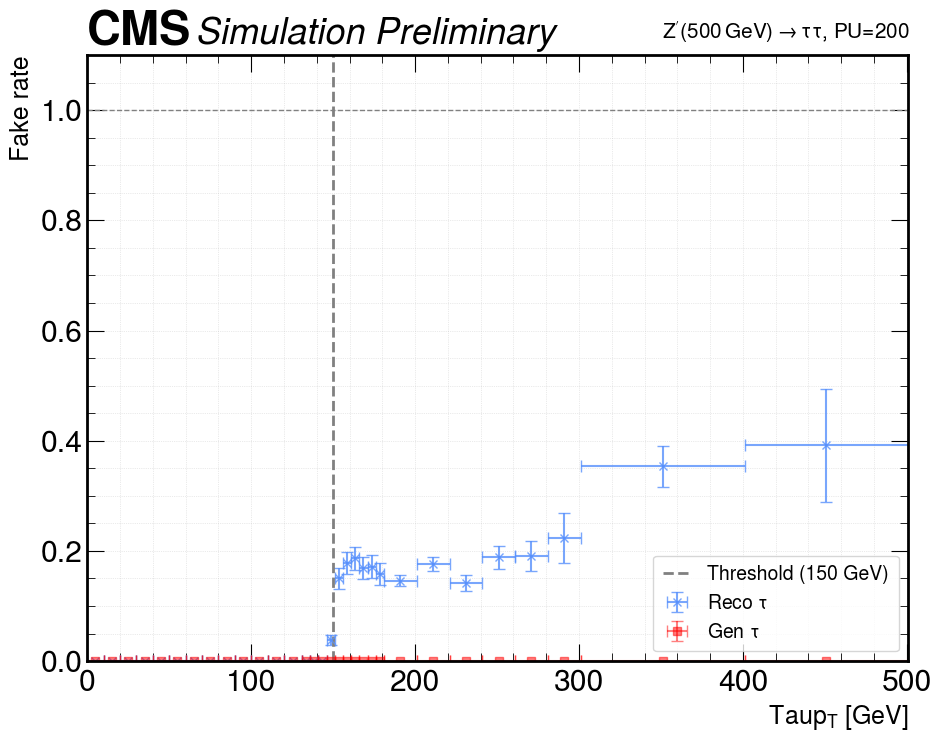

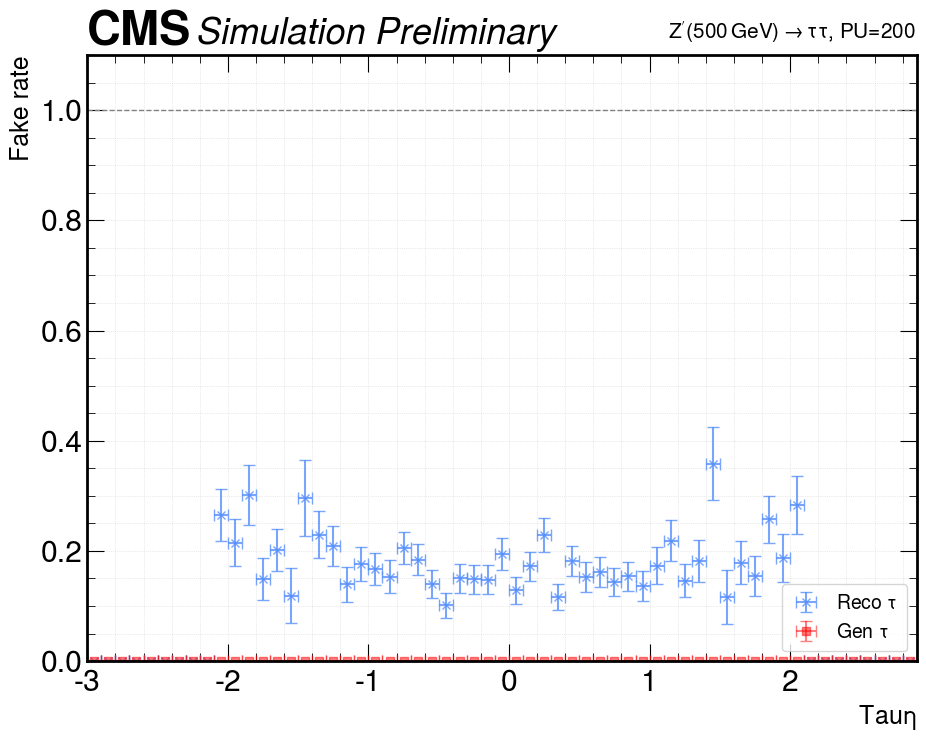

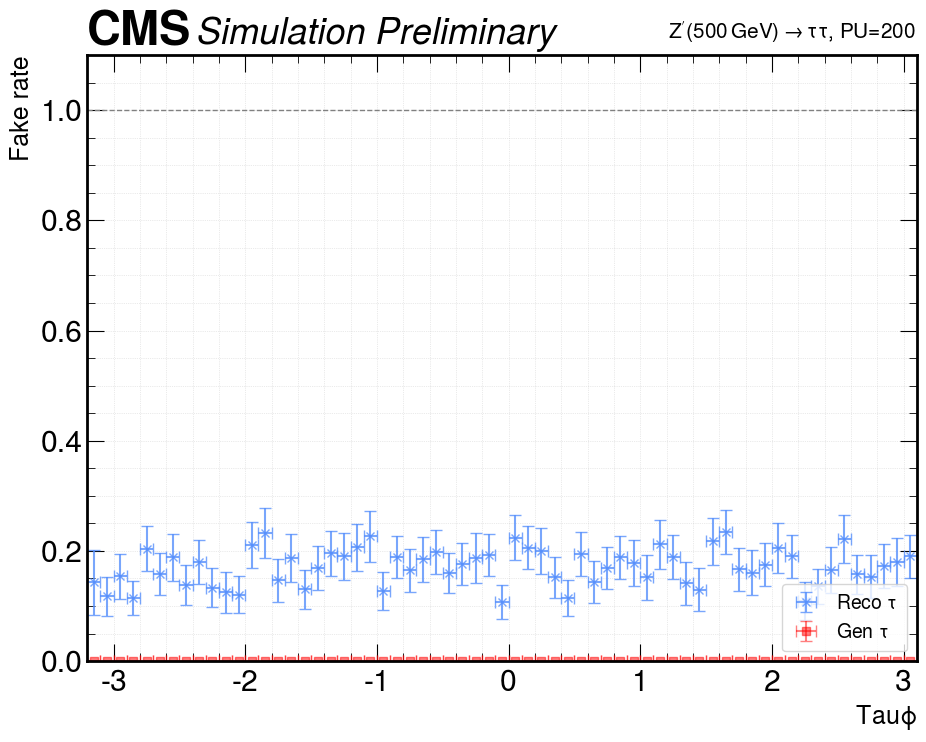

In [4]:
from importlib import import_module
import os
import sys
import argparse
import linecache
import uproot
import vector
import math
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from tqdm import tqdm  # ✅ 진행률 표시
import glob
import json
vector.register_awkward()
import cmsstyle as CMS
import mplhep as hep
import matplotlib.pyplot as plt
######################
## PT Plot
######################

bins_0 = np.arange(0, 130, 10)
bins_1 = np.arange(131, 180, 5)
bins_2 = np.arange(181, 300, 20)
bins_3 = np.arange(301, 601, 100)
bins_pt = np.concatenate((bins_0, bins_1, bins_2, bins_3))

counts_num_reco, edges_pt = np.histogram(num_pt_reco_150, bins=bins_pt)
counts_den_reco, _        = np.histogram(den_pt_reco_150, bins=bins_pt)
counts_num_gen,  _        = np.histogram(num_pt_gen_150,  bins=bins_pt)
counts_den_gen,  _        = np.histogram(den_pt_gen_150,  bins=bins_pt)

ratio_reco = np.divide(counts_num_reco, counts_den_reco,
                       out=np.zeros_like(counts_num_reco, dtype=float),
                       where=(counts_den_reco != 0))
ratio_gen  = np.divide(counts_num_gen,  counts_den_gen,
                       out=np.zeros_like(counts_num_gen,  dtype=float),
                       where=(counts_den_gen  != 0))

ratio_err_reco = np.where(counts_den_reco > 0,
                          np.sqrt(ratio_reco * (1 - ratio_reco) / np.maximum(counts_den_reco, 1)), 0)
ratio_err_gen  = np.where(counts_den_gen  > 0,
                          np.sqrt(ratio_gen  * (1 - ratio_gen)  / np.maximum(counts_den_gen,  1)), 0)

bin_centers_pt = (edges_pt[:-1] + edges_pt[1:]) / 2.0
half_widths_pt = (edges_pt[1:]  - edges_pt[:-1]) / 2.0

plt.style.use(hep.style.CMS)
fig, ax = plt.subplots(figsize=(10, 8))

ax.errorbar(bin_centers_pt, ratio_reco, xerr=half_widths_pt, yerr=ratio_err_reco,
            fmt='x', color='C0', ecolor='C0', capsize=4, alpha=0.8, label=r'Reco $\tau$')
ax.errorbar(bin_centers_pt, ratio_gen,  xerr=half_widths_pt, yerr=ratio_err_gen,
            fmt='s', color='red', ecolor='red', capsize=4, alpha=0.5, label=r'Gen $\tau$')

ax.set_xlabel(r' Tau$p_T$ [GeV]', fontsize=18)
ax.set_ylabel('Fake rate', fontsize=18)
ax.set_xlim(edges_pt[0], edges_pt[-1])
ax.set_ylim(0, 1.1)
ax.axvline(x=150, color='gray', linestyle='--', linewidth=2, label='Threshold (150 GeV)')
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1)
ax.legend(loc='lower right', fontsize=14, frameon=True)
ax.grid(which='both', linestyle=':', linewidth=0.5, alpha=0.5)
hep.cms.text("Simulation Preliminary", loc=0, ax=ax)
ax.text(0.7, 1.06, r"$Z'(500\,\mathrm{GeV}) \to \tau\tau$, PU=200",
        transform=ax.transAxes, fontsize=15, va='top', ha='left',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.tight_layout()
plt.show()

# pT > 150 GeV 구간 Fake rate 출력
over_reco = (den_pt_reco_150 >= 150)
over_gen  = (den_pt_gen_150  >= 150)
#print(f"Reco tau Fake rate (pT > 150 GeV): {num_pt_reco_150[num_pt_reco_150 >= 150].shape[0] / num_pt_reco_150[over_reco].shape[0] * 100:.1f}%")
#print(f"Gen  tau Fake rate (pT > 150 GeV): {num_pt_gen_150[num_pt_gen_150 >= 150].shape[0]  / den_pt_gen_150[over_gen].shape[0]   * 100:.1f}%")


######################
## ETA Plot (pT > 150 GeV 이벤트만)
######################

bins_eta = np.arange(-3.0, 3.0, 0.1)

# pT > 150 컷 적용
num_eta_reco_cut = num_eta_reco_150[num_pt_reco_150 >= 150]
den_eta_reco_cut = den_eta_reco_150[den_pt_reco_150 >= 150]
num_eta_gen_cut  = num_eta_gen_150[ num_pt_gen_150  >= 150]
den_eta_gen_cut  = den_eta_gen_150[ den_pt_gen_150  >= 150]

counts_num_reco, edges_eta = np.histogram(num_eta_reco_cut, bins=bins_eta)
counts_den_reco, _         = np.histogram(den_eta_reco_cut, bins=bins_eta)
counts_num_gen,  _         = np.histogram(num_eta_gen_cut,  bins=bins_eta)
counts_den_gen,  _         = np.histogram(den_eta_gen_cut,  bins=bins_eta)

ratio_reco = np.divide(counts_num_reco, counts_den_reco,
                       out=np.zeros_like(counts_num_reco, dtype=float),
                       where=(counts_den_reco != 0))
ratio_gen  = np.divide(counts_num_gen,  counts_den_gen,
                       out=np.zeros_like(counts_num_gen,  dtype=float),
                       where=(counts_den_gen  != 0))

ratio_err_reco = np.where(counts_den_reco > 0,
                          np.sqrt(ratio_reco * (1 - ratio_reco) / np.maximum(counts_den_reco, 1)), 0)
ratio_err_gen  = np.where(counts_den_gen  > 0,
                          np.sqrt(ratio_gen  * (1 - ratio_gen)  / np.maximum(counts_den_gen,  1)), 0)

bin_centers_eta = (edges_eta[:-1] + edges_eta[1:]) / 2.0
half_widths_eta = (edges_eta[1:]  - edges_eta[:-1]) / 2.0

plt.style.use(hep.style.CMS)
fig, ax = plt.subplots(figsize=(10, 8))

ax.errorbar(bin_centers_eta, ratio_reco, xerr=half_widths_eta, yerr=ratio_err_reco,
            fmt='x', color='C0', ecolor='C0', capsize=4, alpha=0.8, label=r'Reco $\tau$')
ax.errorbar(bin_centers_eta, ratio_gen,  xerr=half_widths_eta, yerr=ratio_err_gen,
            fmt='s', color='red', ecolor='red', capsize=4, alpha=0.5, label=r'Gen $\tau$')

ax.set_xlabel(r' Tau$\eta$', fontsize=18)
ax.set_ylabel('Fake rate', fontsize=18)
ax.set_xlim(edges_eta[0], edges_eta[-1])
ax.set_ylim(0, 1.1)
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1)
ax.legend(loc='lower right', fontsize=14, frameon=True)
ax.grid(which='both', linestyle=':', linewidth=0.5, alpha=0.5)
hep.cms.text("Simulation Preliminary", loc=0, ax=ax)
ax.text(0.7, 1.06, r"$Z'(500\,\mathrm{GeV}) \to \tau\tau$, PU=200",
        transform=ax.transAxes, fontsize=15, va='top', ha='left',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.tight_layout()
plt.show()


######################
## PHI Plot (pT > 150 GeV 이벤트만)
######################

bins_phi = np.arange(-3.2, 3.2, 0.1)

num_phi_reco_cut = num_phi_reco_150[num_pt_reco_150 >= 150]
den_phi_reco_cut = den_phi_reco_150[den_pt_reco_150 >= 150]
num_phi_gen_cut  = num_phi_gen_150[ num_pt_gen_150  >= 150]
den_phi_gen_cut  = den_phi_gen_150[ den_pt_gen_150  >= 150]

counts_num_reco, edges_phi = np.histogram(num_phi_reco_cut, bins=bins_phi)
counts_den_reco, _         = np.histogram(den_phi_reco_cut, bins=bins_phi)
counts_num_gen,  _         = np.histogram(num_phi_gen_cut,  bins=bins_phi)
counts_den_gen,  _         = np.histogram(den_phi_gen_cut,  bins=bins_phi)

ratio_reco = np.divide(counts_num_reco, counts_den_reco,
                       out=np.zeros_like(counts_num_reco, dtype=float),
                       where=(counts_den_reco != 0))
ratio_gen  = np.divide(counts_num_gen,  counts_den_gen,
                       out=np.zeros_like(counts_num_gen,  dtype=float),
                       where=(counts_den_gen  != 0))

ratio_err_reco = np.where(counts_den_reco > 0,
                          np.sqrt(ratio_reco * (1 - ratio_reco) / np.maximum(counts_den_reco, 1)), 0)
ratio_err_gen  = np.where(counts_den_gen  > 0,
                          np.sqrt(ratio_gen  * (1 - ratio_gen)  / np.maximum(counts_den_gen,  1)), 0)

bin_centers_phi = (edges_phi[:-1] + edges_phi[1:]) / 2.0
half_widths_phi = (edges_phi[1:]  - edges_phi[:-1]) / 2.0

plt.style.use(hep.style.CMS)
fig, ax = plt.subplots(figsize=(10, 8))

ax.errorbar(bin_centers_phi, ratio_reco, xerr=half_widths_phi, yerr=ratio_err_reco,
            fmt='x', color='C0', ecolor='C0', capsize=4, alpha=0.8, label=r'Reco $\tau$')
ax.errorbar(bin_centers_phi, ratio_gen,  xerr=half_widths_phi, yerr=ratio_err_gen,
            fmt='s', color='red', ecolor='red', capsize=4, alpha=0.5, label=r'Gen $\tau$')

ax.set_xlabel(r' Tau$\phi$', fontsize=18)
ax.set_ylabel('Fake rate', fontsize=18)
ax.set_xlim(edges_phi[0], edges_phi[-1])
ax.set_ylim(0, 1.1)
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1)
ax.legend(loc='lower right', fontsize=14, frameon=True)
ax.grid(which='both', linestyle=':', linewidth=0.5, alpha=0.5)
hep.cms.text("Simulation Preliminary", loc=0, ax=ax)
ax.text(0.7, 1.06, r"$Z'(500\,\mathrm{GeV}) \to \tau\tau$, PU=200",
        transform=ax.transAxes, fontsize=15, va='top', ha='left',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.tight_layout()
plt.show()

In [19]:
# gen matching 실패한 이벤트가 몇 개인지 확인
print(f"전체 이벤트: {len(events_flag_150)}")
print(f"gen match 실패 (fake 후보): {sum(events_flag_150)}")
print(f"fake 후보 중 trigger 통과: {sum(np.array(events_flag_150) & np.array(tau_trigger_filter_150))}")

전체 이벤트: 7307
gen match 실패 (fake 후보): 1346
fake 후보 중 trigger 통과: 989


In [20]:
# ── Step 1: events_flag 자체 확인 ──
events_flag_arr = np.array(events_flag_150, dtype=bool)
tau_trigger_arr = np.array(tau_trigger_filter_150, dtype=bool)

print(f"전체 이벤트: {len(events_flag_arr)}")
print(f"events_flag True (fake 후보/분모): {events_flag_arr.sum()}")
print(f"trigger True: {tau_trigger_arr.sum()}")
print(f"fake 후보 & trigger (분자): {(events_flag_arr & tau_trigger_arr).sum()}")
print(f"단순 비율: {(events_flag_arr & tau_trigger_arr).sum() / events_flag_arr.sum() * 100:.1f}%")

# ── Step 2: returns_num_den 안의 den/num 크기 확인 ──
print(f"\nden_pt_reco_150 길이: {len(den_pt_reco_150)}")
print(f"num_pt_reco_150 길이: {len(num_pt_reco_150)}")
print(f"단순 비율: {len(num_pt_reco_150)/len(den_pt_reco_150)*100:.1f}%")

# ── Step 3: pT > 150 컷 후 확인 ──
over_den = den_pt_reco_150 >= 150
over_num = num_pt_reco_150 >= 150
print(f"\npT>150 den: {over_den.sum()}")
print(f"pT>150 num: {over_num.sum()}")
print(f"pT>150 비율: {over_num.sum()/over_den.sum()*100:.1f}%")

# ── Step 4: den_pt_reco, num_pt_reco 분포 확인 ──
print(f"\nden_pt_reco min/max: {den_pt_reco_150.min():.1f} / {den_pt_reco_150.max():.1f}")
print(f"num_pt_reco min/max: {num_pt_reco_150.min():.1f} / {num_pt_reco_150.max():.1f}")
print(f"\nden_pt_reco 150 이상 값들:\n{np.sort(den_pt_reco_150[over_den])[:10]}")
print(f"num_pt_reco 150 이상 값들:\n{np.sort(num_pt_reco_150[over_num])[:10]}")

전체 이벤트: 7307
events_flag True (fake 후보/분모): 1346
trigger True: 5597
fake 후보 & trigger (분자): 989
단순 비율: 73.5%

den_pt_reco_150 길이: 7307
num_pt_reco_150 길이: 989
단순 비율: 13.5%

pT>150 den: 5751
pT>150 num: 989
pT>150 비율: 17.2%

den_pt_reco min/max: 130.0 / 995.2
num_pt_reco min/max: 150.0 / 995.2

den_pt_reco 150 이상 값들:
[150.00787 150.01483 150.0165  150.0392  150.04428 150.04913 150.05785
 150.07631 150.10107 150.13089]
num_pt_reco 150 이상 값들:
[150.00787 150.0165  150.13089 150.1347  150.18149 150.24942 150.26395
 150.3862  150.42896 150.58267]
